In [20]:
from matplotlib import pyplot as plt
from sklearn.datasets import fetch_20newsgroups
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score, adjusted_mutual_info_score,normalized_mutual_info_score
from sklearn.model_selection import train_test_split
from gensim.models import Word2Vec,FastText,KeyedVectors
import pandas as pd
import numpy as np
from sklearn.manifold import TSNE
from sklearn.cluster import HDBSCAN
from sklearn.feature_extraction.text import TfidfVectorizer
import re
from sklearn.preprocessing import LabelEncoder
import string
from sklearn.cluster import KMeans, AgglomerativeClustering,HDBSCAN
from sklearn.metrics import silhouette_score

data_20newsgroups = fetch_20newsgroups(subset='all', remove=('headers', 'footers', 'quotes'))
documents_20newsgroups = data_20newsgroups.data
labels_20newsgroups = data_20newsgroups.target
labels_names_20newsgroups = data_20newsgroups.target_names
news_dict = {
    'label': labels_20newsgroups,
    'comment': documents_20newsgroups,
}
news_df = pd.DataFrame(news_dict)
news_df['label_name'] = news_df['label'].apply(lambda x: labels_names_20newsgroups[x])

_, x_test_news, _, y_test_news = train_test_split(
    news_df,
    news_df['label'],
    test_size=0.1,
    random_state=42,
    stratify=news_df['label']
)



df = x_test_news

print("First 10 rows:")
print(df.head(10))

print("\nColumns:")
print(df.columns)

print("\nDataset Info:")
print(df.info()
)
# Check summary statistics
print("\nSummary Statistics:")
print(df.describe(include='all'))

First 10 rows:
       label                                            comment  \
16313      8  If anyone has the current Moto Guzzi National ...   
12        19  930418\n\nDo what thou wilt shall be the whole...   
5705       6                                                      
17808      1  \n    Yes.  There are many methods of renderin...   
9913      10  \n\n\n\n\n\n\n\n\nAs if an aluminum stick bein...   
17490      3  : This may be the dumbest question of the year...   
8617      11  \n[...]>\n[...]>\n\nIf the data isn't there wh...   
4088       1  Does anyone out there have or know of,  line d...   
18606      9  \n\nI'm confused.  How is it Hal McRae's fault...   
8010      15  \nNot quite correct.  Biblical teaching expect...   

                     label_name  
16313           rec.motorcycles  
12           talk.religion.misc  
5705               misc.forsale  
17808             comp.graphics  
9913           rec.sport.hockey  
17490  comp.sys.ibm.pc.hardware  
8617     

In [22]:
# Preprocessing text data

def preprocess_text(text):
    text = text.lower()  # lowercase
    text = ''.join([char for char in text if char not in string.punctuation])  # remove punctuation
    tokens = text.split()
    tokens = [word for word in tokens if len(word)>3]  # remove short words
    return ' '.join(tokens)

# Apply preprocessing
df['Clean_Text'] = df['comment'].apply(preprocess_text)
# sentences by cleaned text
sentences = df['Clean_Text'].apply(lambda x: x.split()).tolist()
# Train model and create embeddings using TF-IDF, word2vec methods

# TF-IDF vectorization
tfidf_vectorizer = TfidfVectorizer(
    max_features=3000,
    ngram_range=(1, 2),
    min_df=5,
    max_df=0.7,
    sublinear_tf=True)
tfidf_embeddings = tfidf_vectorizer.fit_transform(df['Clean_Text'])

# Encode true labels
label_encoder = LabelEncoder()
print(type(x_test_news))
true_labels = df['label']
# Output the shape of the features
print('TF-IDF embedddings shape:',tfidf_embeddings.shape)

# Word2Vec training
w2v_model = Word2Vec(sentences=sentences, vector_size=100, window=5, min_count=2, seed=42)

# function returns word2vec embeddings
# parameters:
    # setences: the givven setences to be embeddings
    # model: the used model(trained) to create embeddings
    # vector_size: the vector size explicity
def w2v_vector(sentences, model, vector_size=100):
    valid_vectors = [model.wv[word] for word in sentences if word in model.wv]
    return np.mean(valid_vectors, axis=0) if valid_vectors else np.zeros(vector_size)
#create w2vec embeddings based on text sentences
w2v_embeddings = np.array([w2v_vector(sentence, w2v_model, 100) for sentence in sentences])
print('word2vec embeddings shape:',w2v_embeddings.shape)

<class 'pandas.core.frame.DataFrame'>
TF-IDF embedddings shape: (1885, 3000)
word2vec embeddings shape: (1885, 100)


In [30]:
# Global functions for KMeans across all the feature extraction algorythms
    # elbow_evaluate_kmeans(data,algorythm): elbow visualization by given embeddings and feature extraction algorythm,
    # sihouette_score_kmeans(data,algorythm): silhouette score visualization by given embeddings and feature extraction algorythm,
    # kmeans_evaluated_k(data,k=5):apply optimal KMeans by given embeddings and optimal evaluated k as we know ground truth is 5


# Global function:
# plot the elbow line for KMeans clustering evaluation
# parameters:
    #data = embeddings
    #algorythm:string  TF-IDF or word2vec for explanation in plots title 
def elbow_evaluate_kmeans(data,algorythm):
    k_values = range(1, 25)
    inertia_values = []
    for k in k_values:
        kmeans = KMeans(n_clusters=k,
                        # init='k-means++',
                        # n_init=10,
                        # max_iter=500,
                        # tol=1e-4,
                        # random_state=42
                        )
        kmeans.fit(data)
        inertia_values.append(kmeans.inertia_)

    #Plot the elbow for evaluation k
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, inertia_values,
             marker='o',
             linestyle='--',
             color='b')
    plt.title(f"Elbow Method {algorythm} for Optimal K")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Inertia")
    plt.xticks(k_values)
    plt.grid()
    plt.show()
    
# Global function: Sillhouette score evaluation for KMeans clustering 
# parameters:
    #data = embeddings
    #algorythm:string  TF-IDF or word2vec for explanation in plots title 
def sihouette_score_kmeans(data,algorythm):
    k_values = range(2, 25)
    silhouette_scores = []
    # compute KMeans for each k and store silhouette score
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42)
        labels = kmeans.fit_predict(data)
        score = silhouette_score(data, labels)
        silhouette_scores.append(score)
    
    # plot the Silhouette Score
    plt.figure(figsize=(8, 6))
    plt.plot(k_values, silhouette_scores,
             marker='o',
             linestyle='--',
             color='g')
    plt.title(f"{algorythm} Silhouette Method for Optimal K for KMeans clustering")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.xticks(k_values)
    plt.grid()
    plt.show()


# Apply Optimal KMeans clustering
# parameters:
    # data = embeddings.toarray()
    # k:int  the optimal evaluatede n_clusters
    # returns implemented kmeans clusterer
def kmeans_evaluated_k(data,k=20):

    # optimized KMeans with optimal K
    kmeans_evaluated = KMeans(
        n_clusters=k,
        init='k-means++',
        n_init=10,
        # max_iter=500,
        tol=1e-4,
        random_state=42)  
    # apply kmeans on given data and return
    return kmeans_evaluated.fit(data)
 

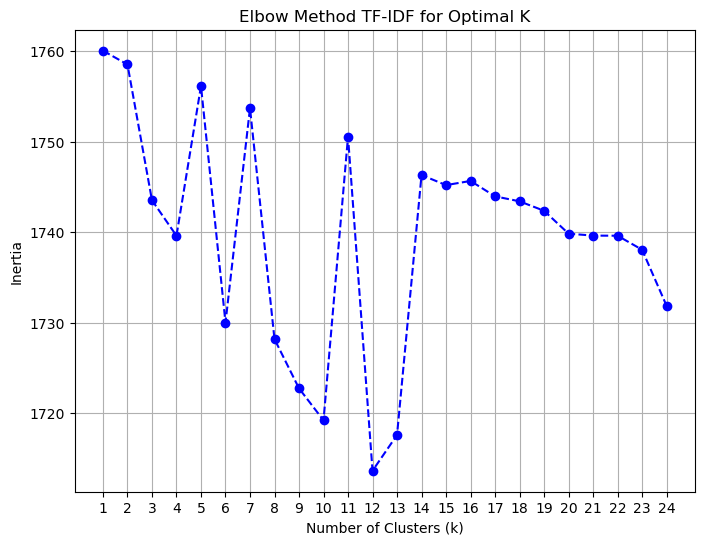

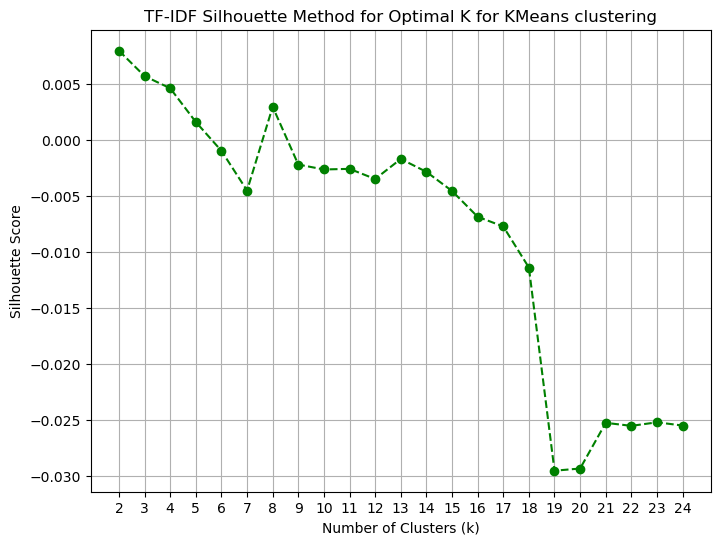

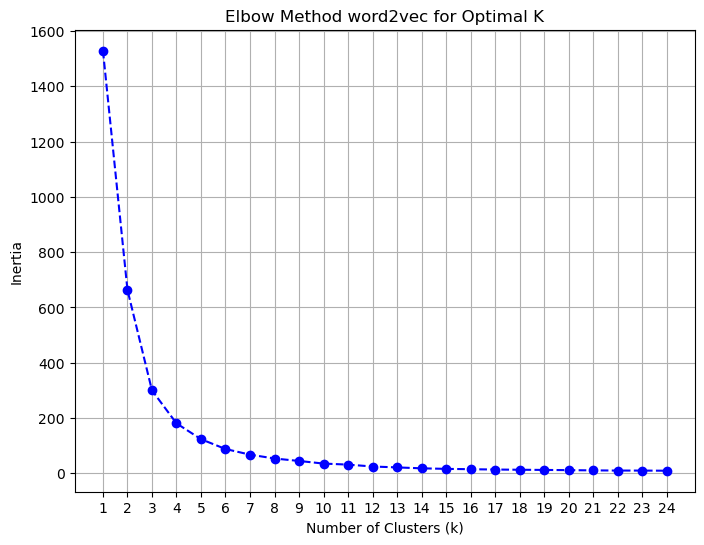

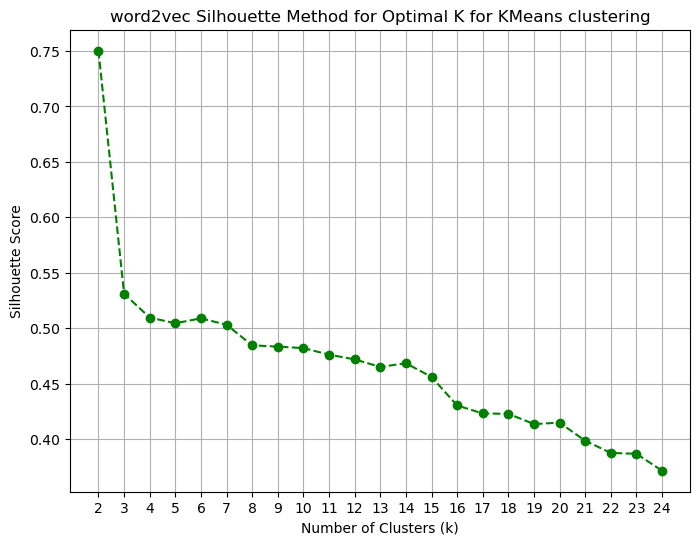

In [32]:
# KMEANS visualize clustering evaluation methods Elbow, silhouette score
# TF-IDF, word2vec
# apply optimal KMEANS with k=5

# TF-IDF
# TF-IDF visualize elbow method
elbow_evaluate_kmeans(data=tfidf_embeddings,algorythm='TF-IDF')
# Visualize silhouette score
sihouette_score_kmeans(tfidf_embeddings,'TF-IDF')
# apply KMeans with optimal k=5
kmeans_optimal = kmeans_evaluated_k(data=tfidf_embeddings,k=5)
# cluster labels
kmeans_tfidf_labels = kmeans_optimal.labels_


# word2vec
# word2vec visualize elbow method
elbow_evaluate_kmeans(w2v_embeddings,algorythm='word2vec')
# Visualize silhouette score
sihouette_score_kmeans(w2v_embeddings,algorythm='word2vec')
# apply KMeans word2vec with optimal k=5
kmeans_optimal_w2v = kmeans_evaluated_k(data=w2v_embeddings,k=5)
# cluster labels
kmeans_w2v_labels = kmeans_optimal_w2v.labels_



In [49]:
## AGGLOMERATIVE global functions:
    # visualize clustering evaluation 
    # implement the optimal agglomerative clusterer


# Sillhouette Method for Agglomerative clustering
# parameters:
    # void
    #data = embeddings
    #algorythm:string  TF-IDF or word2vec for explanation in plots title
def sihouette_score_Agglo(data,algorythm):
    k_values_agglo = range(2, 25)
    silhouette_scores_agglo = []
    # compute agglomerative for each k and store silhouette score
    for k_agglo in k_values_agglo:
        agglo = AgglomerativeClustering(
            n_clusters=k_agglo,  # Number of clusters
            metric='euclidean',  # Distance metric
            compute_full_tree=True,
            linkage='ward',  # Linkage criterion
            distance_threshold=None  # Distance Threshold, cant have both with n_clusters seted values
    
        )
        labels_agglo = agglo.fit_predict(data)
        score_agglo = silhouette_score(data, labels_agglo)
        silhouette_scores_agglo.append(score_agglo)
    
    # plot the Silhouette Score
    plt.figure(figsize=(8, 6))
    plt.plot(k_values_agglo, silhouette_scores_agglo,
             marker='o',
             linestyle='--',
             color='g')
    plt.title(f"{algorythm} Silhouette Method for Optimal K Agglomerative clustering ")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.xticks(k_values_agglo)
    plt.grid()
    plt.show()



# Optimal Agglo clustering
# parameters:
    # data = embeddings.toarray()
    # k:int  the optimal evaluatede n_clusters
    # returns agglomerative predicted labels
def agglo_evaluated_k(data, k=20):
    agg_clustering = AgglomerativeClustering(
        n_clusters=k,
        metric='euclidean',
        compute_full_tree=True,
        linkage='ward'
    )
    return agg_clustering.fit_predict(data)



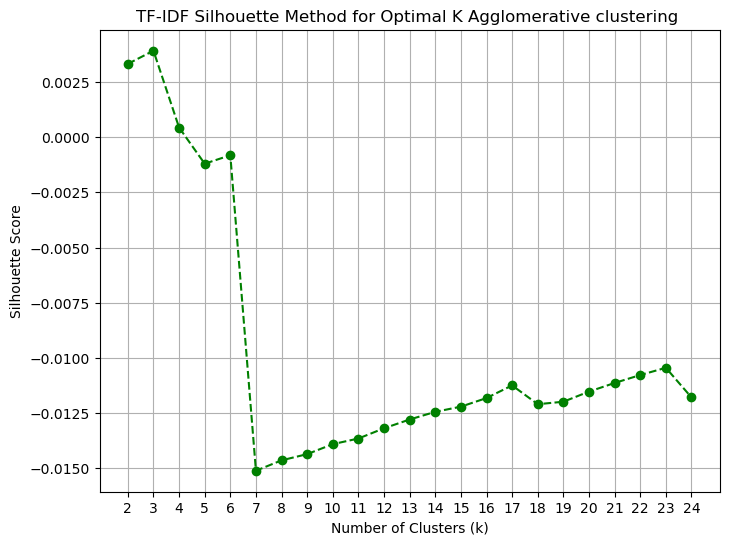

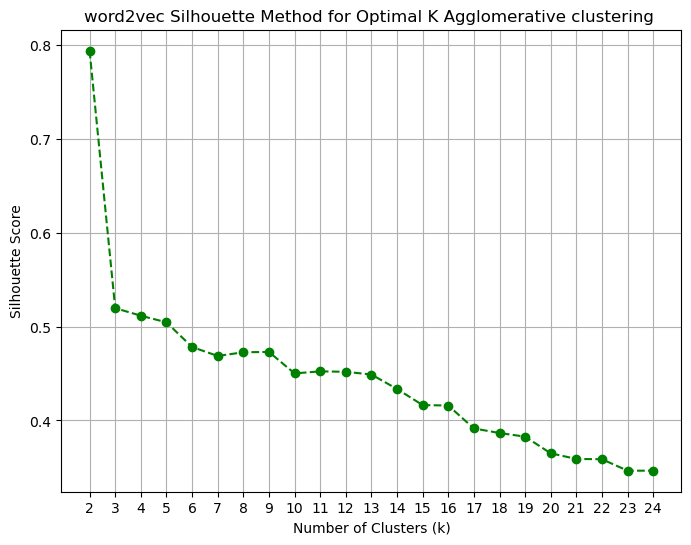

In [48]:
# # Elbow visualize plot
# # Visualize silhouette score
# # Implement the optimal agglomerative clustering


# TF-IDF
# Evaluation agglomerative with silhouette score on TF-IDF embeddings
sihouette_score_Agglo(data = tfidf_embeddings.toarray(),algorythm='TF-IDF')
# Optimal K found from the evaluation
k_optimized_agglo = 5
# # apply Agglomerative with optimal k from silhouette score evaluation
agglo_tfidf = agglo_evaluated_k(data=tfidf_embeddings.toarray(),k=k_optimized_agglo)
# cluster labels
agglo_tfidf_labels = agglo_evaluated_k(tfidf_embeddings.toarray(),k=k_optimized_agglo)


# word2vec
# Visualize silhouette score
sihouette_score_Agglo(data=w2v_embeddings,algorythm='word2vec')
# apply KMeans word2vec with optimal k=5
agglo_optimal_w2v = agglo_evaluated_k(data=w2v_embeddings,k=5)
# cluster labels
agglo_w2v_labels = agglo_optimal_w2v


In [54]:
# Sillhouette Method for HDBSCAN clustering
def sihouette_score_hdbsc(data,algorythm):
    k_nearest_hdbsc = range(2,20)
    silhouette_scores_hdbsc = []
    # compute HDBSCAN for each k and store silhouette score
    for k_hdbsc in k_nearest_hdbsc:
        clusterer = HDBSCAN(
            # min_cluster_size=15,   # Minimum cluster size
            min_samples=k_hdbsc,         # The parameter k nearest-neighbor
            metric='euclidean',    # Distance metric
            cluster_selection_method='eom',  # Cluster extraction method
            # max_cluster_size=50,  # Maximum cluster size
        )
        labels_hdbsc = clusterer.fit_predict(data)
        score_hdbsc = silhouette_score(data, labels_hdbsc)
        silhouette_scores_hdbsc.append(score_hdbsc)
    
    # plot the Silhouette Score
    plt.figure(figsize=(8, 6))
    plt.plot(k_nearest_hdbsc, silhouette_scores_hdbsc,
             marker='o',
             linestyle='--',
             color='g')
    plt.title(f"{algorythm} Silhouette Method for Optimal min_samples HDBSCAN clustering ")
    plt.xlabel("Number of Clusters (k)")
    plt.ylabel("Silhouette Score")
    plt.xticks(k_nearest_hdbsc)
    plt.grid()
    plt.show()

# HDBSCAN implementation 
def hdbscan_clusterer(data,min_samp):
    clusterer = HDBSCAN(
    min_samples=min_samp,         # The parameter k nearest-neighbor
    metric='euclidean',    # Distance metric
    cluster_selection_method='eom',  # Cluster extraction method
    )
    # predicted clustering labels array
    predictions = clusterer.fit_predict(data)

    # return prediction labels and clusterer
    return clusterer,predictions


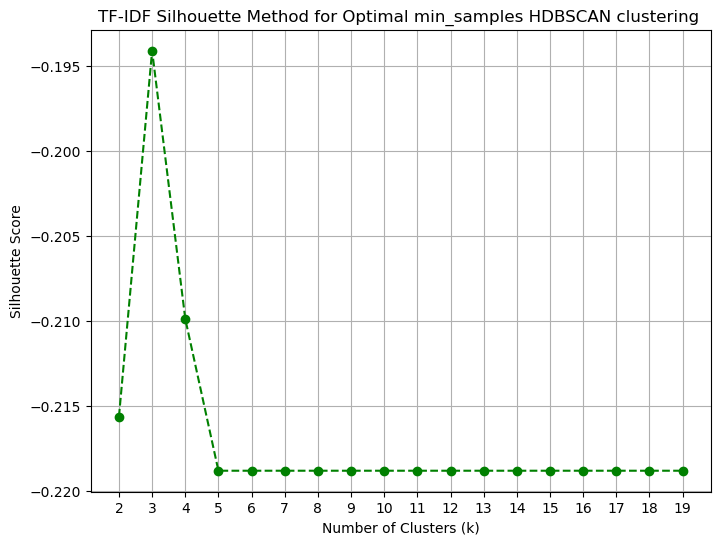

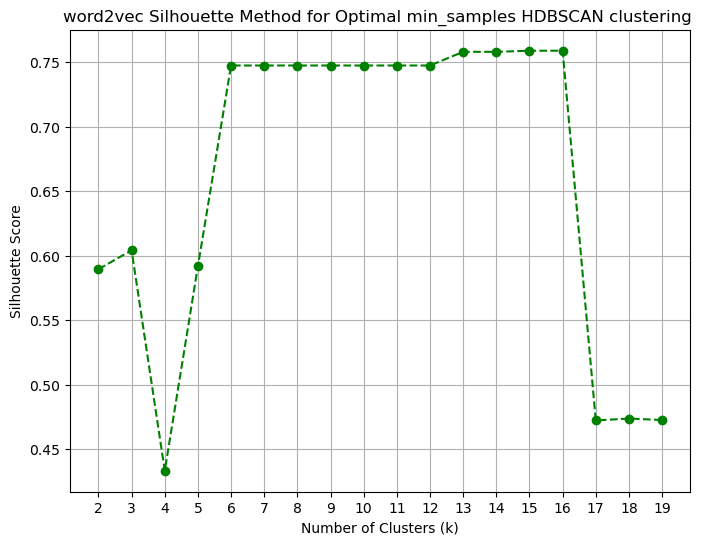

In [58]:
# HDBSCAN clustering

# TF-IDF
# hdbscan TF-IDF silhouette score with min samples
sihouette_score_hdbsc(data=tfidf_embeddings,algorythm = 'TF-IDF')
# predicted clustering labes HDBSCAN on TF-IDF embeddings
clusterer_tfidf,predictions_tfidf = hdbscan_clusterer(tfidf_embeddings,min_samp=3)
#  hdbscan clusterer 
hdbscan_tfidf = clusterer_tfidf
labels_tfidf_hdbsc = predictions_tfidf



# word2vec
# hdbscan word2vec silhouette score with min samples
sihouette_score_hdbsc(data=w2v_embeddings,algorythm = 'word2vec')
# predicted clustering labes HDBSCAN on TF-IDF embeddings
clusterer_w2v,predictions_w2v = hdbscan_clusterer(w2v_embeddings,min_samp=16)
#  hdbscan clusterer 
hdbscan_w2v = clusterer_w2v
labels_w2v_hdbsc = predictions_w2v


hdbsc_eval =  {
        'NMI_TFIDF': normalized_mutual_info_score(true_labels, labels_tfidf_hdbsc),
        'ARI_TFIDF': adjusted_rand_score(true_labels,labels_tfidf_hdbsc),
        'AMI_TFIDF': adjusted_mutual_info_score(true_labels, labels_tfidf_hdbsc),
        'NMI_W2V': normalized_mutual_info_score(true_labels, labels_tfidf_hdbsc),
        'ARI_W2V': adjusted_rand_score(true_labels,labels_tfidf_hdbsc),
        'AMI_W2V': adjusted_mutual_info_score(true_labels, labels_tfidf_hdbsc),
    }
#print(hdbsc_eval)

                    NMI       ARI       AMI
TFIDF_KMeans   0.143690  0.044136  0.135901
TFIDF_Agglo    0.136164  0.028940  0.127364
TFIDF_HDBSCAN  0.046199  0.000642  0.005162
W2V_KMeans     0.024094  0.003901  0.014730
W2V_Agglo      0.021262  0.003159  0.011288


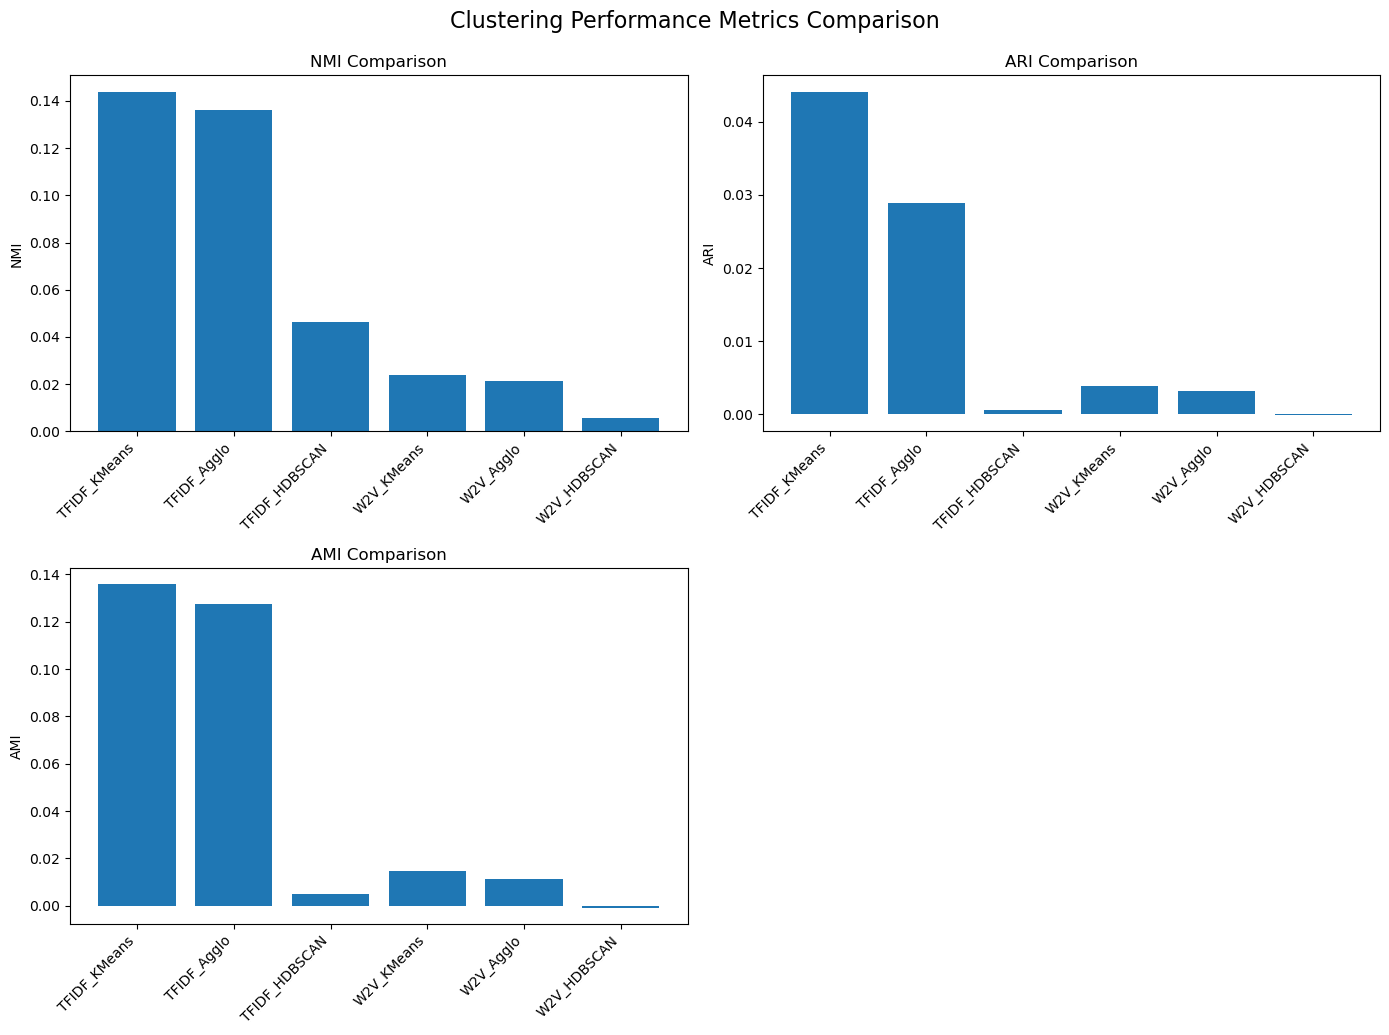

In [60]:
# Evaluation metrics for every algorythm

# Evaluation function
def evaluate_clustering(true_labels, predicted_labels):
    return {
        'NMI': normalized_mutual_info_score(true_labels, predicted_labels),
        'ARI': adjusted_rand_score(true_labels, predicted_labels),
        'AMI': adjusted_mutual_info_score(true_labels, predicted_labels),
    }

evaluation_metrics = {}


## TF-IDF Clustering:
    # KMeans
evaluation_metrics['TFIDF_KMeans'] = evaluate_clustering(true_labels, kmeans_tfidf_labels)
    # Agglomerative 
evaluation_metrics['TFIDF_Agglo'] = evaluate_clustering(true_labels, agglo_tfidf_labels)
    # HDBSCAN 
evaluation_metrics['TFIDF_HDBSCAN'] = evaluate_clustering(true_labels, labels_tfidf_hdbsc)


# Word2Vec Clustering:
    # KMeans
evaluation_metrics['W2V_KMeans'] = evaluate_clustering(true_labels, kmeans_w2v_labels)
    # Agglomerative 
evaluation_metrics['W2V_Agglo'] = evaluate_clustering(true_labels, agglo_w2v_labels)
    # HDBSCAN
evaluation_metrics['W2V_HDBSCAN'] = evaluate_clustering(true_labels, labels_w2v_hdbsc)

import json
# Print as JSON-formatted string
# print(json.dumps(evaluation_metrics, indent=4))


evaluation_df = pd.DataFrame(evaluation_metrics).T
print(evaluation_df.head())
#----
# Plot results
metrics = ['NMI', 'ARI', 'AMI']
plt.figure(figsize=(14, 10))
for i, metric in enumerate(evaluation_df.columns, 1):
    plt.subplot(2, 2, i)
    plt.bar(evaluation_df.index, evaluation_df[metric])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.tight_layout()

plt.suptitle("Clustering Performance Metrics Comparison", fontsize=16, y=1.03)
plt.show()



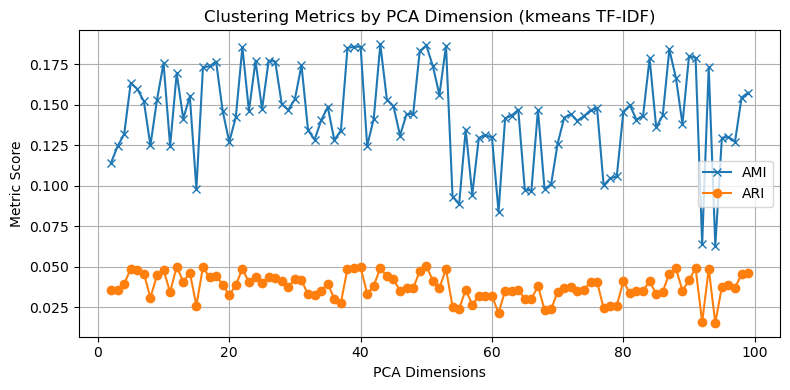

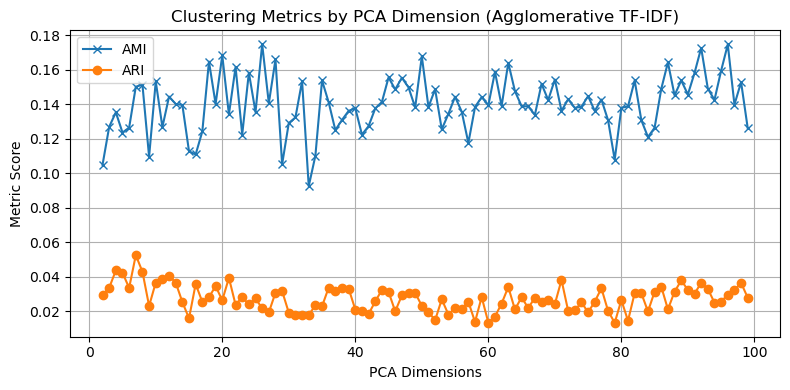

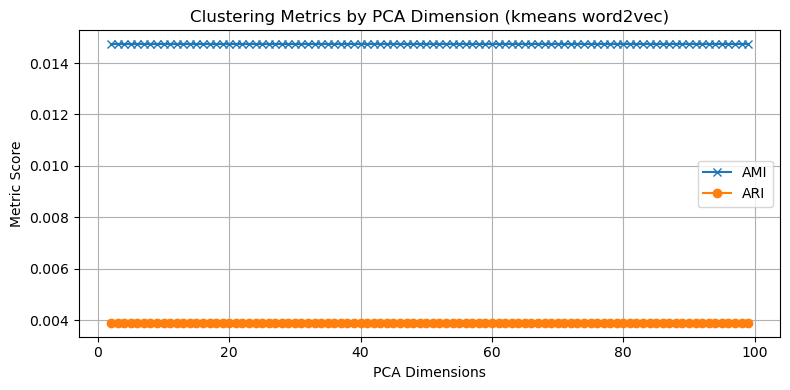

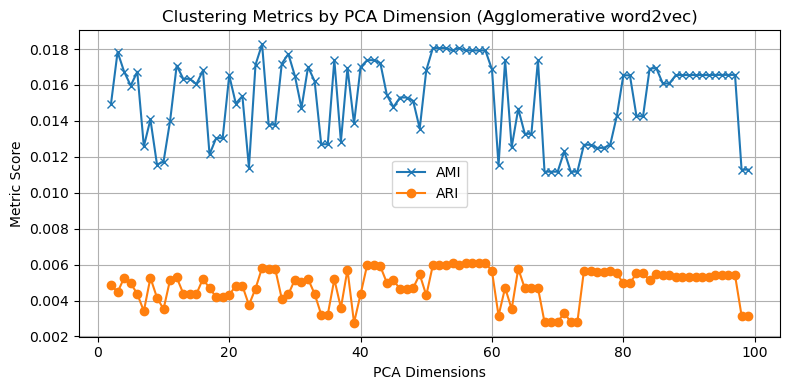

In [62]:
# Evaluation metrics on PCA reduction from 2 to 100

# Dimensionality evaluation function
def evaluate_metrics_over_dimensions(embeddings, method='kmeans',model_='TF-IDF'):
    dims = list(range(2, 100, 1))
    nmi_scores, ari_scores, ami_scores = [], [], []

    for d in dims:
        X_pca = PCA(n_components=d, random_state=42).fit_transform(embeddings)
        if method.lower() == 'kmeans':
            model = KMeans(n_clusters=5, random_state=42)
        elif method.lower() == 'agglomerative':
            model = AgglomerativeClustering(n_clusters=5,metric='euclidean',compute_full_tree=True,linkage='ward')
        else:
            raise ValueError("Unsupported method: choose 'kmeans' or 'agglo'")

        clusters = model.fit_predict(X_pca)
        nmi_scores.append(normalized_mutual_info_score(true_labels, clusters))
        ari_scores.append(adjusted_rand_score(true_labels, clusters))
        ami_scores.append(adjusted_mutual_info_score(true_labels, clusters))

    # Plotting
    plt.figure(figsize=(8, 4))
    plt.plot(dims, ami_scores, marker='x', label='AMI')
    plt.plot(dims, ari_scores, marker='o', label='ARI')
    plt.xlabel("PCA Dimensions")
    plt.ylabel("Metric Score")
    plt.title(f"Clustering Metrics by PCA Dimension ({method} {model_})")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()

evaluate_metrics_over_dimensions(embeddings = tfidf_embeddings, method='kmeans',model_='TF-IDF')
evaluate_metrics_over_dimensions(embeddings = tfidf_embeddings, method='Agglomerative',model_='TF-IDF')
evaluate_metrics_over_dimensions(embeddings = w2v_embeddings, method='kmeans',model_='word2vec')
evaluate_metrics_over_dimensions(embeddings = w2v_embeddings, method='Agglomerative',model_='word2vec')



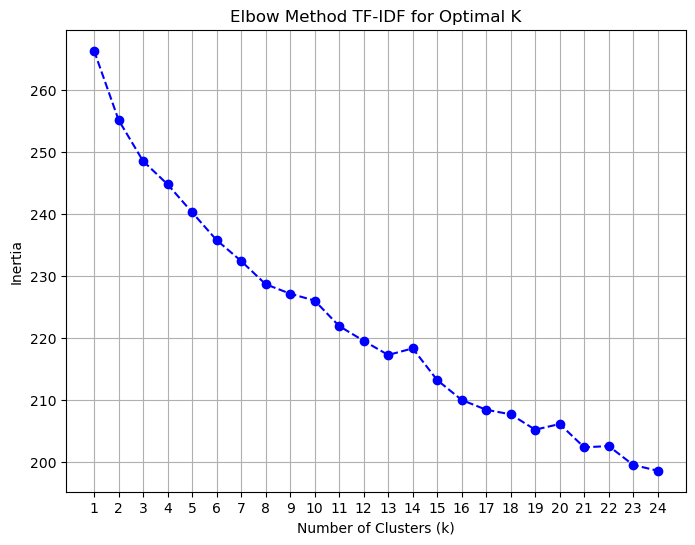

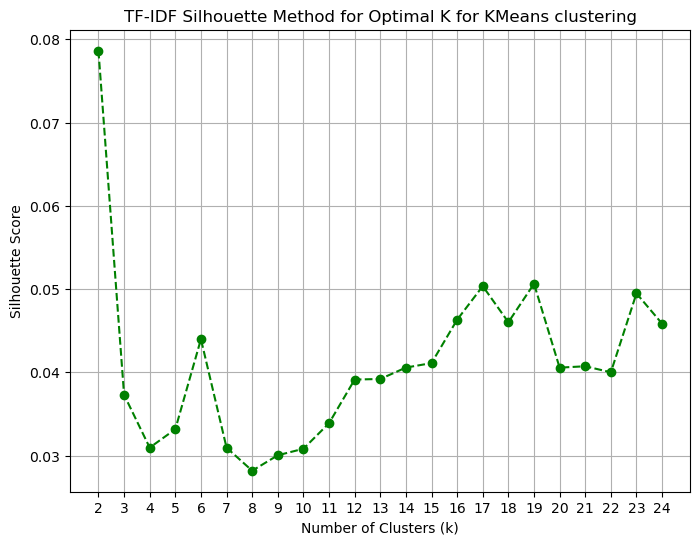

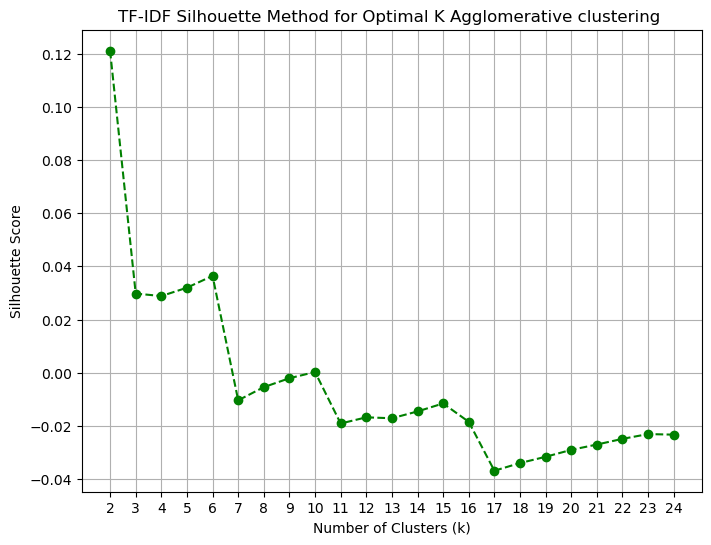

In [66]:
# PCA on TF-IDF embeddings
# apply PCA 50 dismension is both a top of kmeans and aglomerative meetrics ari,ami

# pca with 50 dismensions
pca_tfidf = PCA(n_components=53, random_state=42)
# create pca tfidf embeddings
tfidf_pca_embeddings = pca_tfidf.fit_transform(tfidf_embeddings.toarray())


# __________________________________PCA TF-IDF__________________________________#


    ## _______KMEANS______##
# PCA kmeans visualize elbow method
elbow_evaluate_kmeans(data=tfidf_pca_embeddings,algorythm='TF-IDF')
# Visualize silhouette score
sihouette_score_kmeans(tfidf_pca_embeddings,'TF-IDF')

# KMeans pca apply optimal k
kmeans_tfidf_pca = kmeans_evaluated_k(data=tfidf_pca_embeddings,k=5)
# Kmeans optimal pca labels
kmeans_pca_tfidf_labels = kmeans_tfidf_pca.labels_

    ## ____AGGLOMERATIVE_____##
# Agglomerative PCA visualize silhouette score o min_samples
sihouette_score_Agglo(tfidf_pca_embeddings,'TF-IDF')
# Agglomerative pca labels
agglo_pca_tfidf_labels = agglo_evaluated_k(data=tfidf_pca_embeddings, k=5)

#     ##________HDBSCAN_______##
# # hdbscan PCA TF-IDF silhouette score with min samples
# sihouette_score_hdbsc(data=tfidf_pca_embeddings,algorythm = 'TF-IDF')
# # predicted clustering labes HDBSCAN on TF-IDF embeddings
# clusterer_tfidf_pca,predictions_tfidf_pca = hdbscan_clusterer(tfidf_pca_embeddings,min_samp=2)
# #  hdbscan clusterer 
# hdbscan_tfidf_pca = clusterer_tfidf_pca
# labels_tfidf_hdbsc_pca = predictions_tfidf_pca




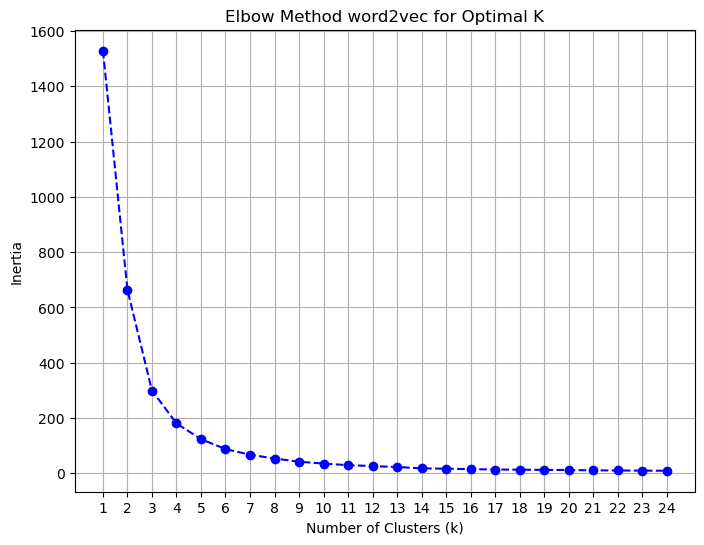

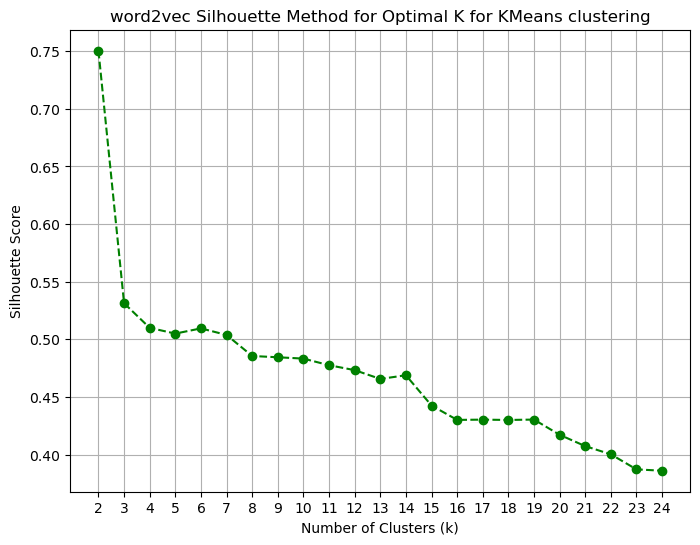

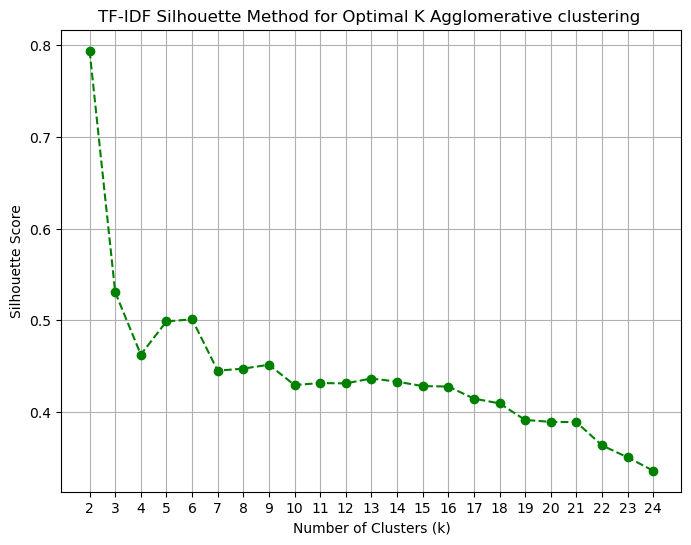

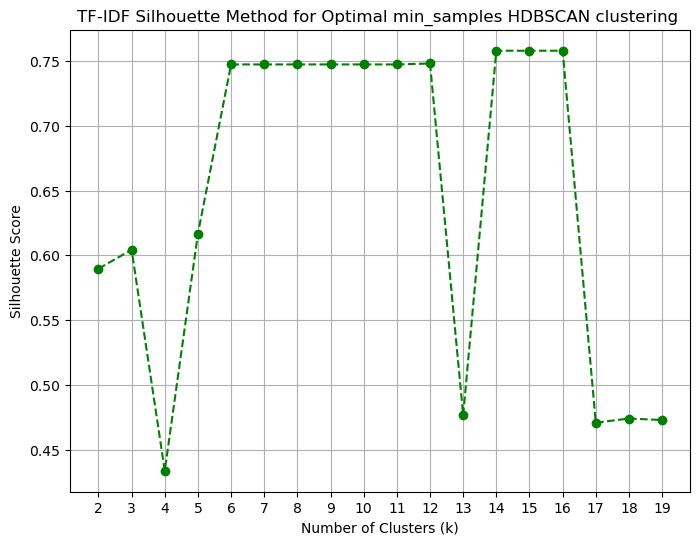

In [69]:
# Visualize evaluation clustering with PCA methods elbow and silhouette score on word2vec embeddings

# __________________________________word2vec__________________________________
# word2vec visualize elbow method
pca_w2v = PCA(n_components=50, random_state=42)
w2v_embeddings_pca= pca_tfidf.fit_transform(w2v_embeddings)

    ## _______KMEANS______##
elbow_evaluate_kmeans(w2v_embeddings_pca,algorythm='word2vec')
# Visualize silhouette score
sihouette_score_kmeans(w2v_embeddings_pca,algorythm='word2vec')
# apply KMeans word2vec with optimal k=5
kmeans_optimal_w2v = kmeans_evaluated_k(data=w2v_embeddings_pca,k=5)
# cluster labels
kmeans_pca_w2v_labels = kmeans_optimal_w2v.labels_

    ## ____AGGLOMERATIVE_____##
# Agglomerative w2v PCA visualize silhouette score o min_samples
sihouette_score_Agglo(w2v_embeddings_pca,'TF-IDF')
# Agglomerative pca labels
agglo_pca_w2v_labels = agglo_evaluated_k(data=w2v_embeddings_pca, k=5)


    ##________HDBSCAN_______##
# hdbscan TF-IDF silhouette score with min samples
sihouette_score_hdbsc(data=w2v_embeddings_pca,algorythm = 'TF-IDF')
# predicted clustering labes HDBSCAN on TF-IDF embeddings
clusterer_w2v_pca,predictions_w2v_pca = hdbscan_clusterer(w2v_embeddings_pca,min_samp=2)
#  hdbscan clusterer 
hdbscan_w2v_pca = clusterer_w2v_pca
hdbsc_pca_w2v_labels = predictions_w2v_pca



                    NMI       ARI       AMI
TFIDF_KMeans   0.143690  0.044136  0.135901
TFIDF_Agglo    0.136164  0.028940  0.127364
TFIDF_HDBSCAN  0.046199  0.000642  0.005162
W2V_KMeans     0.024094  0.003901  0.014730
W2V_Agglo      0.021262  0.003159  0.011288


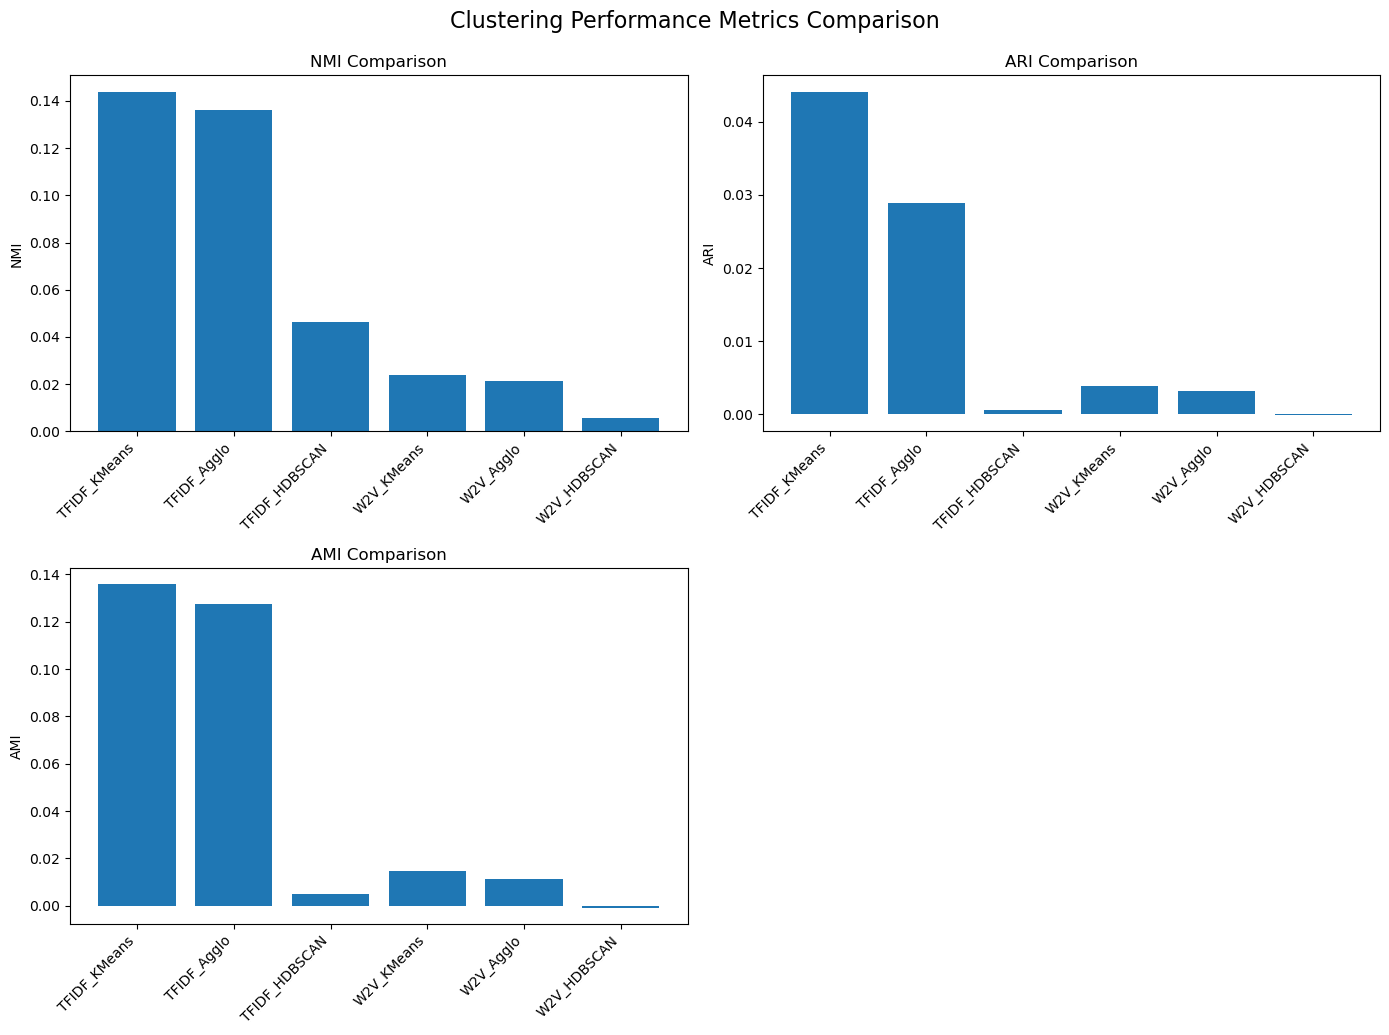

In [71]:
# Evaluation metrics (NMI, ARI, AMI) with pca in both models TF-IDF,word2vec

evaluation_metrics_pca = {}

        ##__________________________TF-IDF metrics________________________##

# KMeans
evaluation_metrics_pca['TFIDF_PCA_KMeans'] = evaluate_clustering(true_labels, kmeans_pca_tfidf_labels)
   # Agglomerative 
evaluation_metrics_pca['TFIDF_Agglo'] = evaluate_clustering(true_labels, agglo_pca_tfidf_labels)
    # HDBSCAN 
evaluation_metrics_pca['TFIDF_HDBSCAN'] = evaluate_clustering(true_labels, labels_tfidf_hdbsc)
evaluation_metrics_pca
metrics_pca_df = pd.DataFrame(evaluation_metrics_pca).T
metrics_pca_df

        ##__________________________word2vec metrics________________________##

    # KMeans
evaluation_metrics_pca['W2V_KMeans'] = evaluate_clustering(true_labels, kmeans_pca_w2v_labels)
    # Agglomerative 
evaluation_metrics_pca['W2V_Agglo'] = evaluate_clustering(true_labels, agglo_pca_w2v_labels)
    # HDBSCAN
evaluation_metrics_pca['W2V_HDBSCAN'] = evaluate_clustering(true_labels, hdbsc_pca_w2v_labels)



evaluation_pca_df = pd.DataFrame(evaluation_metrics).T
print(evaluation_df.head())
#----
# Plot results
metrics = ['NMI', 'ARI', 'AMI']
plt.figure(figsize=(14, 10))
for i, metric in enumerate(evaluation_df.columns, 1):
    plt.subplot(2, 2, i)
    plt.bar(evaluation_df.index, evaluation_df[metric])
    plt.xticks(rotation=45, ha='right')
    plt.title(f'{metric} Comparison')
    plt.ylabel(metric)
    plt.tight_layout()

plt.suptitle("Clustering Performance Metrics Comparison", fontsize=16, y=1.03)
plt.show()
